# Scenario A1 Mixed: Single Supplier — No REC (Mixed Prosumers)

**Description:** Baseline scenario with mixed prosumer characterisation. Single
supplier mandate, one balancing group. Prosumers are modelled as **full prosumers**
— both local load consumption AND RES generation are billed separately, reflecting
the realistic case where a prosumer is also a consuming household or commercial site.

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | None |
| Prosumer type | **Mixed** (RES + local load both billed) |
| Battery | None |

**Research role:** Pure baseline for the mixed-prosumer track. All subsequent
mixed-prosumer scenarios are compared against A1-mixed to quantify the incremental
effect of RECs, multiple suppliers, forecast scheduling, and battery storage.

**Comparison pairs (mixed-prosumer track):**
- A1-mixed vs A2-mixed → value of adding a REC under single-supplier mandate
- A1-mixed vs B1-mixed → effect of introducing a second independent supplier
- A1-mixed vs B2-mixed → combined effect of multi-supplier + REC

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "A1_single_supplier_no_rec_(mixed Prosumers)-Baseline.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="A1 Single Supplier No REC (Mixed Prosumers) - Baseline")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **REC Settlement** - (Skipped for A1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: A1 Single Supplier No REC (Mixed Prosumers) - Baseline
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: A1 Single Supplier No REC (Mixed Prosumers) - Baseline
  System  : Single Supplier Mandate without REC - Scenario A1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (35136, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly a

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – A1 SINGLE SUPPLIER NO REC (MIXED PROSUMERS) - BASELINE

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      174.75
      Balancing Rewards   : €       72.08
      Retail Sales        : €   37,953.39
      ────────────────────────────────────────────
      Total Revenue       : €   38,200.22

    COSTS:
      Market Purchases    : €    5,255.00
      Balancing Penalties  : €       71.73
      Retail Purchases     : €    3,357.64
      ────────────────────────────────────────────
      Total Costs          : €    8,684.37

    PROFIT/LOSS:
      Annual Total         : €   29,515.86
      Monthly Average      : €    2,459.65

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.00 MWh
      BG Actual Position   :       148.07 MWh
      BG Forecast Position :       148.08 MWh




  ANNUAL FINANCIAL SUMMARY – A1 SINGLE SUPPLIER NO REC (MIXED PROSUMERS) - BASELINE

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      174.75
      Balancing Rewards   : €       72.08
      Retail Sales        : €   37,953.39
      ────────────────────────────────────────────
      Total Revenue       : €   38,200.22

    COSTS:
      Market Purchases    : €    5,255.00
      Balancing Penalties  : €       71.73
      Retail Purchases     : €    3,357.64
      ────────────────────────────────────────────
      Total Costs          : €    8,684.37

    PROFIT/LOSS:
      Annual Total         : €   29,515.86
      Monthly Average      : €    2,459.65

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.00 MWh
      BG Actual Position   :       148.07 MWh
      BG Forecast Position :       148.08 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

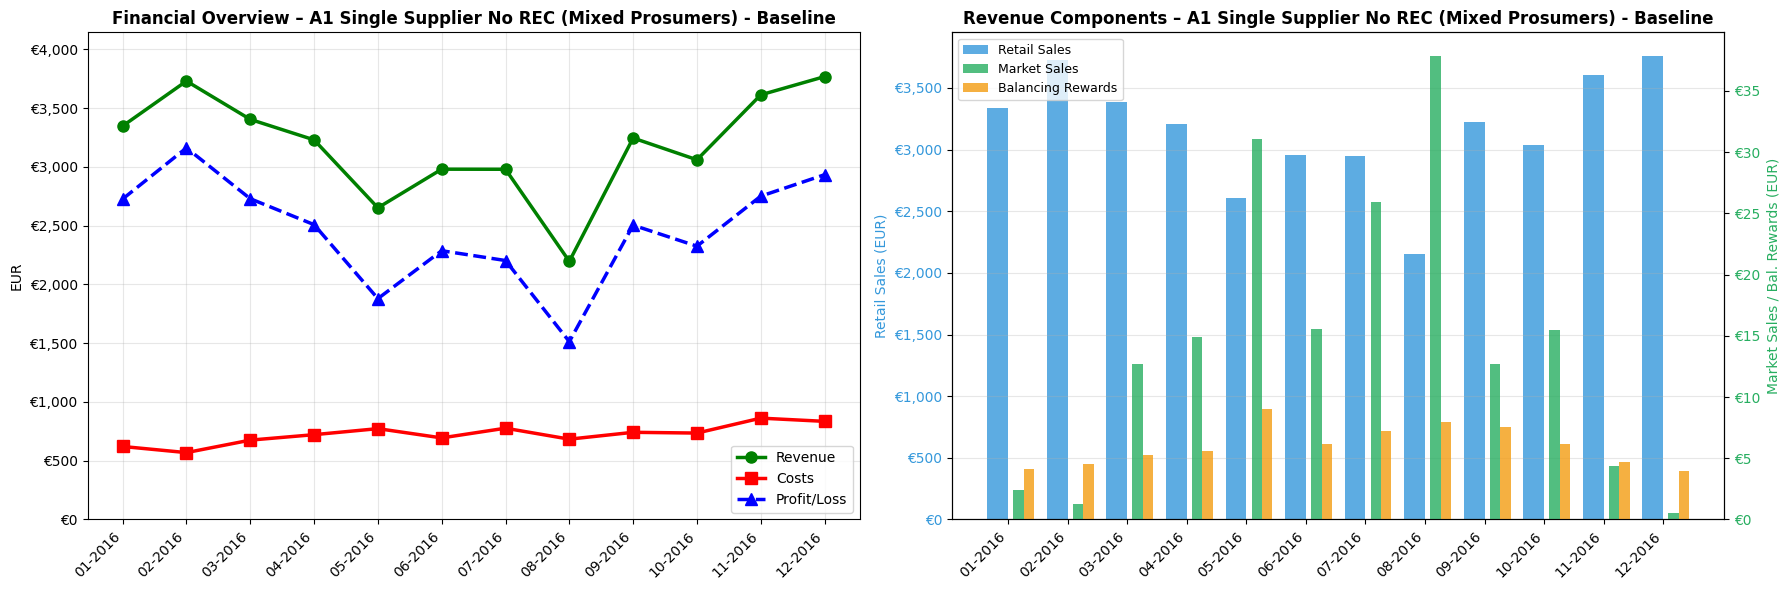

In [29]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

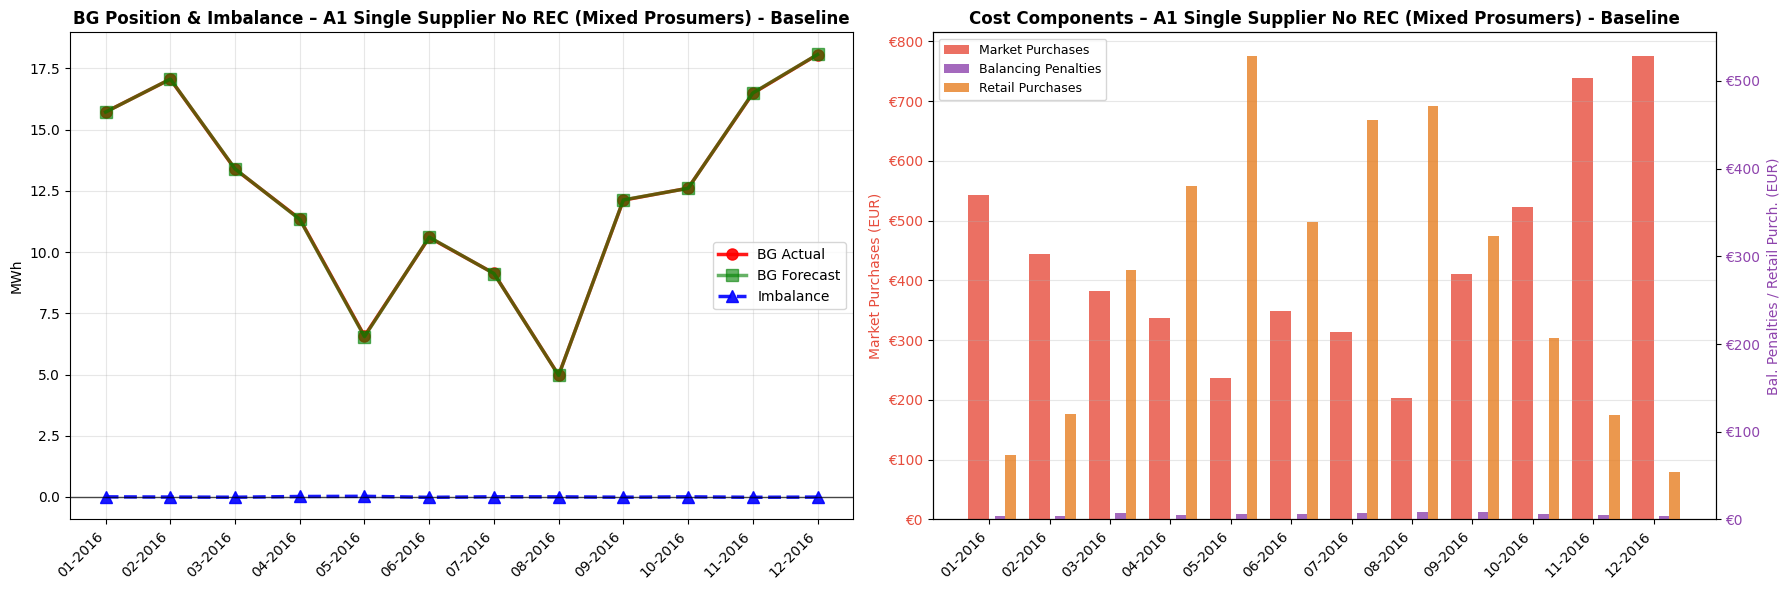

In [30]:
pipe.plot_imbalances()

## 7. Monthly Analysis Data
Display the detailed monthly analysis DataFrame with all financial metrics broken down by month.

In [7]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,purchase_costs_eur,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,17.532878,0.074406,602.281473,1.797368,-1.715450,0.024128,29.579375,...,73.821276,2.439240,4.131813,3340.375280,3346.946333,543.221850,3.759606,73.821276,620.802733,2726.143600
1,02-2016,SUP_A,BG_A,19.107729,0.065242,494.289117,1.000277,-1.958210,0.018489,22.463459,...,120.725650,1.288584,4.491525,3723.843232,3729.623341,443.587695,4.392938,120.725650,568.706284,3160.917057
2,03-2016,SUP_A,BG_A,16.039708,0.803732,430.267683,11.430321,-1.769806,0.066489,24.094009,...,284.738878,12.666183,5.287190,3385.628868,3403.582240,382.896448,7.306179,284.738878,674.941505,2728.640735
3,04-2016,SUP_A,BG_A,13.856790,0.740528,382.911009,13.180574,-1.689523,0.091747,25.257687,...,379.974048,14.870016,5.622943,3208.834028,3229.326987,336.375362,4.916169,379.974048,721.265579,2508.061408
4,05-2016,SUP_A,BG_A,10.088920,2.039926,272.346920,26.667326,-1.279075,0.222535,22.993579,...,528.880123,31.054428,8.983114,2611.262593,2651.300135,237.357643,6.359462,528.880123,772.597228,1878.702908
5,06-2016,SUP_A,BG_A,12.938537,0.718319,394.866299,13.262446,-1.509338,0.099243,27.651608,...,339.558274,15.582818,6.141136,2958.174974,2979.898929,348.456915,5.787373,339.558274,693.802563,2286.096366
6,07-2016,SUP_A,BG_A,12.010879,1.250522,358.242903,22.689101,-1.492098,0.143167,27.138380,...,455.366228,25.913868,7.214823,2946.082216,2979.210907,313.747924,7.233370,455.366228,776.347522,2202.863385
7,08-2016,SUP_A,BG_A,7.787415,1.567736,233.787697,32.690097,-1.046827,0.206594,27.268374,...,471.846808,37.888653,7.923552,2149.930009,2195.742214,202.513268,8.709591,471.846808,683.069667,1512.672547
8,09-2016,SUP_A,BG_A,14.312761,0.463877,462.929502,10.440456,-1.632672,0.084286,30.137590,...,323.213901,12.703429,7.519984,3224.748089,3244.971501,410.206575,7.952185,323.213901,741.372661,2503.598840
9,10-2016,SUP_A,BG_A,14.612840,0.380204,585.042861,12.835531,-1.552765,0.074982,36.908256,...,206.526637,15.439746,6.164883,3038.231537,3059.836166,522.318391,6.098839,206.526637,734.943867,2324.892298


In [8]:
import pandas as pd
df = pipe.es_monthly_analysis_df
imb_cols = [c for c in df.columns if 'imbalance' in c.lower() or 'balancing' in c.lower()]
annual_imb = df.groupby('supplier_id')[imb_cols].agg(
    lambda x: x.sum() if pd.api.types.is_numeric_dtype(x) else x.iloc[0]
)
print("=== IMBALANCE ANALYSIS (Annual) ===\n")
for col in imb_cols:
    val = annual_imb[col].iloc[0]
    if isinstance(val, (int, float)):
        unit = "MWh" if "mwh" in col else "€"
        print(f"  {col:45s}: {val:>12,.4f} {unit}")

# Monthly breakdown
mwh_cols = [c for c in imb_cols if 'mwh' in c and pd.api.types.is_numeric_dtype(df[c])]
month_col = [c for c in df.columns if c.lower() in ('month', 'period', 'date')]
if month_col:
    grp = month_col[0]
else:
    grp = df.index
print(f"\n=== MONTHLY IMBALANCE (MWh) ===")
df.groupby(grp)[mwh_cols].sum()

=== IMBALANCE ANALYSIS (Annual) ===

  balancing_group_actual_mwh                   :     148.0748 MWh
  balancing_group_forecast_mwh                 :     148.0753 MWh
  imbalance_mwh                                :      -0.0005 MWh
  imbalance_price_eur_per_mwh                  :     386.0141 MWh
  imbalance_penalty                            :      71.7272 €
  imbalance_reward                             :      72.0813 €
  revenue_balancing_rewards_eur                :      72.0813 €
  cost_balancing_penalties_eur                 :      71.7272 €

=== MONTHLY IMBALANCE (MWh) ===


=== IMBALANCE ANALYSIS (Annual) ===

  balancing_group_actual_mwh                   :     148.0748 MWh
  balancing_group_forecast_mwh                 :     148.0753 MWh
  imbalance_mwh                                :      -0.0005 MWh
  imbalance_price_eur_per_mwh                  :     386.0141 MWh
  imbalance_penalty                            :      71.7272 €
  imbalance_reward                             :      72.0813 €
  revenue_balancing_rewards_eur                :      72.0813 €
  cost_balancing_penalties_eur                 :      71.7272 €

=== MONTHLY IMBALANCE (MWh) ===


,balancing_group_actual_mwh,balancing_group_forecast_mwh,imbalance_mwh,imbalance_price_eur_per_mwh
0,15.722893,15.718894,0.003999,43.178360
1,17.061466,17.065788,-0.004322,26.566688
2,13.388356,13.399681,-0.011325,18.326912
3,11.353013,11.334992,0.018021,16.201212
4,6.572908,6.547384,0.025524,17.224956
5,10.596436,10.611637,-0.015201,23.953281
6,9.130836,9.125092,0.005744,30.322786
7,4.969873,4.966258,0.003615,33.750242
8,12.121024,12.131926,-0.010902,40.851691
9,12.609189,12.604889,0.004300,39.806882


In [9]:
# Extract all key metrics for LaTeX table
df = pipe.es_monthly_analysis_df
s = df.groupby('supplier_id').sum(numeric_only=True).iloc[0]

print("=== BALANCING ===")
print(f"BG Actual Position           : {s['balancing_group_actual_mwh']:.4f} MWh")
print(f"BG Forecast Position         : {s['balancing_group_forecast_mwh']:.4f} MWh")
print(f"Imbalance (net)              : {s['imbalance_mwh']:.4f} MWh")
print(f"Imbalance Penalty            : {s['imbalance_penalty']:.2f} €")
print(f"Imbalance Reward             : {s['imbalance_reward']:.2f} €")
print(f"Net Balancing Settlement     : {s['imbalance_reward'] - s['imbalance_penalty']:.2f} €")
pos = "LONG" if s['imbalance_mwh'] < 0 else "SHORT"
print(f"System Position              : {pos}")

print("\n=== FINANCIALS ===")
print(f"Revenue Energy Market Sales  : {s['revenue_energy_market_sales_eur']:.2f} €")
print(f"Revenue Balancing Rewards    : {s['revenue_balancing_rewards_eur']:.2f} €")
print(f"Revenue Retail Sales         : {s['revenue_retail_sales_eur']:.2f} €")
print(f"Total Revenue                : {s['total_revenue_eur']:.2f} €")
print(f"Cost Market Purchases        : {s['cost_energy_market_purchases_eur']:.2f} €")
print(f"Cost Balancing Penalties     : {s['cost_balancing_penalties_eur']:.2f} €")
print(f"Cost Retail Purchases        : {s['cost_retail_purchases_eur']:.2f} €")
print(f"Total Costs                  : {s['total_costs_eur']:.2f} €")
print(f"Profit/Loss                  : {s['profit_loss_eur']:.2f} €")

=== BALANCING ===
BG Actual Position           : 148.0748 MWh
BG Forecast Position         : 148.0753 MWh
Imbalance (net)              : -0.0005 MWh
Imbalance Penalty            : 71.73 €
Imbalance Reward             : 72.08 €
Net Balancing Settlement     : 0.35 €
System Position              : LONG

=== FINANCIALS ===
Revenue Energy Market Sales  : 174.75 €
Revenue Balancing Rewards    : 72.08 €
Revenue Retail Sales         : 37953.39 €
Total Revenue                : 38200.22 €
Cost Market Purchases        : 5255.00 €
Cost Balancing Penalties     : 71.73 €
Cost Retail Purchases        : 3357.64 €
Total Costs                  : 8684.37 €
Profit/Loss                  : 29515.86 €


In [10]:
monthly_pl = df.groupby(df.index)['profit_loss_eur'].sum()
print(f"Monthly average: €{monthly_pl.mean():.2f}")
print(f"Monthly minimum: €{monthly_pl.min():.2f}")
print(f"Monthly maximum: €{monthly_pl.max():.2f}")

Monthly average: €2459.65
Monthly minimum: €1512.67
Monthly maximum: €3160.92


In [4]:
df = pipe.es_monthly_analysis_df[['datetime', 'cost_energy_market_purchases_eur', 'cost_balancing_penalties_eur', 'cost_retail_purchases_eur', 'total_costs_eur']].copy()
df.columns = ['Month', 'Market_Purchases', 'Balancing_Penalties', 'Retail_Purchases', 'Total_Costs']
print(df.to_string(index=False))
print(f"\nAnnual Totals:")
print(f"  Market Purchases:    €{df['Market_Purchases'].sum():,.2f}")
print(f"  Balancing Penalties: €{df['Balancing_Penalties'].sum():,.2f}")
print(f"  Retail Purchases:    €{df['Retail_Purchases'].sum():,.2f}")
print(f"  Total Costs:         €{df['Total_Costs'].sum():,.2f}")

  Month  Market_Purchases  Balancing_Penalties  Retail_Purchases  Total_Costs
01-2016        543.221850             3.759606         73.821276   620.802733
02-2016        443.587695             4.392938        120.725650   568.706284
03-2016        382.896448             7.306179        284.738878   674.941505
04-2016        336.375362             4.916169        379.974048   721.265579
05-2016        237.357643             6.359462        528.880123   772.597228
06-2016        348.456915             5.787373        339.558274   693.802563
07-2016        313.747924             7.233370        455.366228   776.347522
08-2016        202.513268             8.709591        471.846808   683.069667
09-2016        410.206575             7.952185        323.213901   741.372661
10-2016        522.318391             6.098839        206.526637   734.943867
11-2016        738.056417             4.979490        118.927736   861.963644
12-2016        776.258436             4.231951         54.061706